# ニューラルネットワークの普遍性定理

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

活性化関数の定義

step関数はsigmoidで近似する

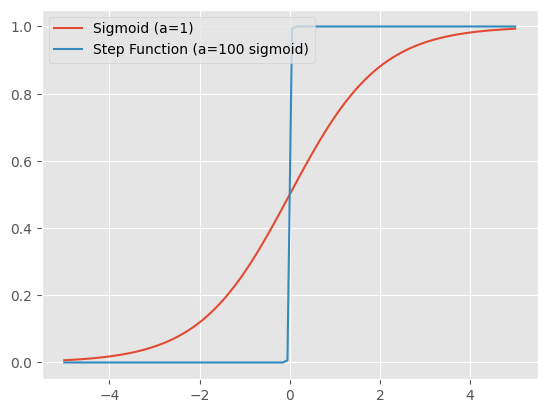

In [2]:
def identify(x):
    return x

def sigmoid(x, a=1):
    return 1 / (1 + np.exp(-a * x))

# Approximating step function with sigmoid
def step(x):
    return sigmoid(x, a=100)

x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x, a=1), label="Sigmoid (a=1)")
plt.plot(x, step(x), label="Step Function (a=100 sigmoid)")
plt.legend()
plt.show()

## Perceptronを用いたpulse関数の再現

In [3]:
class Perceptron:
    def __init__(self, w: list[float], b: float, activation=identify):
        self.w = w
        self.b = b
        self.activation = activation

    def __call__(self, x: list[float]):
        return self.activation(sum([xi * wi for xi, wi in zip(x, self.w)]) + self.b)

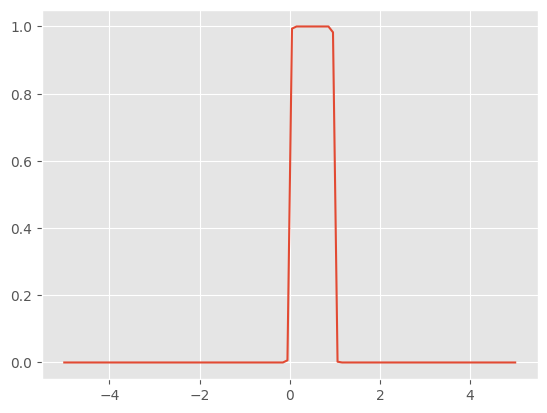

In [4]:
x1, x2 = 0, 1
per1 = Perceptron(w=[1], b=-x1, activation=step)
per2 = Perceptron(w=[1], b=-x2, activation=step)
per3 = Perceptron(w=[1, -1], b=0, activation=identify)

def pulse(x):
    x = [x]
    return per3([per1(x), per2(x)])

y = [pulse(xi) for xi in x]
plt.plot(x, y);

## NeuralNetによる関数の近似

In [5]:
class Layer:
    def __init__(self, W: np.ndarray, b: np.ndarray, activation: callable):
        self.W = W
        self.b = b
        self.activation = activation

    def __call__(self, x):
        return self.activation(np.dot(self.W.T, x) + self.b)

class NeuralNet:
    def __init__(self, *layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

def approximate(f, x_range=(-4, 4), precision=0.2):
    x = np.arange(*x_range, precision)
    y = f(x)
    n = len(x)

    W1 = np.ones((1, n * 2))
    b1 = np.zeros(n * 2)
    for i in range(n):
        b1[i*2] = -x[i]
        b1[i*2 + 1] = -(x[i] + precision)
    layer1 = Layer(W1, b1, step)

    W2 = np.zeros((n * 2, 1))
    b2 = 0
    for i in range(n):
        W2[i*2] = y[i]
        W2[i*2 + 1] = -y[i]
    layer2 = Layer(W2, b2, identify)

    net = NeuralNet(layer1, layer2)
    return net

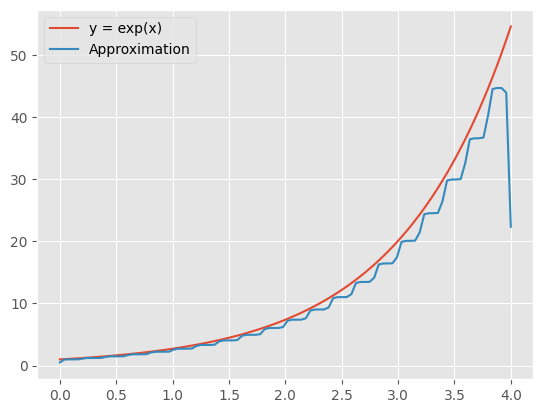

In [6]:
f = np.exp
x_range = (0, 4)
precision = 0.2

x = np.linspace(*x_range, 100)
y = f(x)

app_exp = approximate(f, x_range=x_range, precision=precision)
y_app = [app_exp(np.array([xi])) for xi in x]

plt.plot(x, y, label="y = exp(x)")
plt.plot(x, y_app, label="Approximation")
plt.legend();

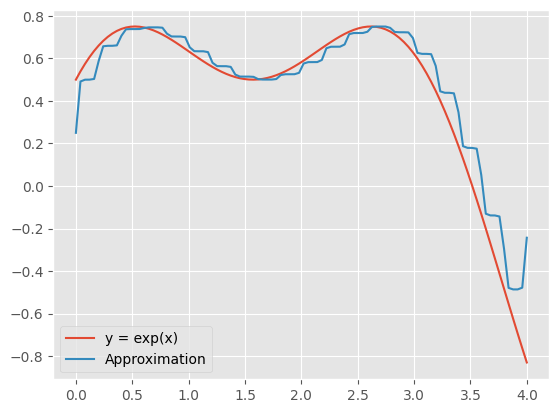

In [7]:
f = lambda x: np.sin(x) + 0.5 * np.cos(2 * x)
x_range = (0, 4)
precision = 0.2

x = np.linspace(*x_range, 100)
y = f(x)

app_exp = approximate(f, x_range=x_range, precision=precision)
y_app = [app_exp(np.array([xi])) for xi in x]

plt.plot(x, y, label="y = exp(x)")
plt.plot(x, y_app, label="Approximation")
plt.legend();